In [38]:
import os
import cv2
import glob
import numpy as np
import matplotlib.pyplot as plt
import shutil
import time
import warnings
import pandas as pd
import yaml
from tqdm import tqdm
warnings.filterwarnings('ignore')

# ===================================================
# KONFIGURASI PATH
# ===================================================
BASE_PATH = "D:/Tugas Kuliah/Semester 4/Research Metodology/Dataset"

DATASET_PATHS = {
    "red_light"        : os.path.join(BASE_PATH, "red_light"),
    "helmet"           : os.path.join(BASE_PATH, "helmet"),
    "helm_spion_sepatu": os.path.join(BASE_PATH, "helm_spion_sepatu"),
    "seat_belt"        : os.path.join(BASE_PATH, "seat_belt"),
    "license_plate"    : os.path.join(BASE_PATH, "license_plate"),
}

# Folder tujuan gabungan
base_dst = os.path.join(BASE_PATH, "global")

# Sample image untuk demo preprocessing
SAMPLE_IMAGE = os.path.join(BASE_PATH, "license_plate", "train", "images")
# Ambil gambar pertama dari license_plate
sample_files = [
    f for f in os.listdir(SAMPLE_IMAGE)
    if f.lower().endswith(('.jpg', '.png', '.jpeg'))
]
SAMPLE_IMAGE = os.path.join(SAMPLE_IMAGE, sample_files[0]) if sample_files else None

# ===================================================
# GLOBAL CLASS MAPPING (18 Kelas)
# ===================================================
CLASS_NAMES = {
    0 : 'bike',
    1 : 'bus',
    2 : 'car',
    3 : 'green_light',
    4 : 'motobike',
    5 : 'red_light',
    6 : 'stop_line',
    7 : 'truck',
    8 : 'yellow_light',
    9 : 'license_plate',
    10: 'with_helmet',
    11: 'without_helmet',
    12: 'sepatu',
    13: 'spion',
    14: 'tidak_pakai_sepatu',
    15: 'mobile',
    16: 'seatbelt',
    17: 'windshield',
}
NUM_CLASSES = len(CLASS_NAMES)

# ===================================================
# CLASS MAP PER DATASET
# (ID lama → ID global baru)
# ===================================================

# red_light: bike=0, bus=1, car=2, green_light=3,
#            motobike=4, red_light=5, stop_line=6,
#            truck=7, yellow_light=8
class_map_redlight = {
    0: 0,   # bike         → bike
    1: 1,   # bus          → bus
    2: 2,   # car          → car
    3: 3,   # green_light  → green_light
    4: 4,   # motobike     → motobike
    5: 5,   # red_light    → red_light
    6: 6,   # stop_line    → stop_line
    7: 7,   # truck        → truck
    8: 8,   # yellow_light → yellow_light
}

# helmet: Plate=0, WithHelmet=1, WithoutHelmet=2
class_map_helmet = {
    0: 9,   # Plate         → license_plate
    1: 10,  # WithHelmet    → with_helmet
    2: 11,  # WithoutHelmet → without_helmet
}

# helm_spion_sepatu: Sepatu=0, Spion=1,
#                   Tidak Pakai Helm=2,
#                   Tidak Pakai Sepatu=3, helm=4
class_map_spion = {
    0: 12,  # Sepatu           → sepatu
    1: 13,  # Spion            → spion
    2: 11,  # Tidak Pakai Helm → without_helmet
    3: 14,  # Tidak Pakai Sepatu → tidak_pakai_sepatu
    4: 10,  # helm             → with_helmet
}

# seat_belt: mobile=0, seatbelt=1, windshield=2
class_map_seatbelt = {
    0: 15,  # mobile     → mobile
    1: 16,  # seatbelt   → seatbelt
    2: 17,  # windshield → windshield
}

# license_plate: License_Plate=0
class_map_plate = {
    0: 9,   # License_Plate → license_plate
}

print("✅ Konfigurasi berhasil dimuat!")
print(f"   Base path    : {BASE_PATH}")
print(f"   Output path  : {base_dst}")
print(f"   Num classes  : {NUM_CLASSES}")
print(f"\n📋 Daftar Kelas Global:")
for id, name in CLASS_NAMES.items():
    print(f"   ID {id:>2} → {name}")


✅ Konfigurasi berhasil dimuat!
   Base path    : D:/Tugas Kuliah/Semester 4/Research Metodology/Dataset
   Output path  : D:/Tugas Kuliah/Semester 4/Research Metodology/Dataset\global
   Num classes  : 18

📋 Daftar Kelas Global:
   ID  0 → bike
   ID  1 → bus
   ID  2 → car
   ID  3 → green_light
   ID  4 → motobike
   ID  5 → red_light
   ID  6 → stop_line
   ID  7 → truck
   ID  8 → yellow_light
   ID  9 → license_plate
   ID 10 → with_helmet
   ID 11 → without_helmet
   ID 12 → sepatu
   ID 13 → spion
   ID 14 → tidak_pakai_sepatu
   ID 15 → mobile
   ID 16 → seatbelt
   ID 17 → windshield


In [39]:
def merge_to_global(src_path, dataset_name, class_map):
    """
    Menggabungkan dataset ke dalam folder global dengan
    mempertahankan pemisahan train/valid/test.

    Args:
        src_path     : Folder dataset asli
        dataset_name : Nama unik prefix untuk file
        class_map    : {id_lama: id_baru}
    """
    splits = ['train', 'valid', 'test']
    total_copied = 0

    for split in splits:
        img_src = os.path.join(src_path, split, 'images')
        lbl_src = os.path.join(src_path, split, 'labels')

        if not os.path.exists(img_src):
            print(f"  ⚠️  Folder tidak ditemukan: {img_src}, di-skip.")
            continue

        # Buat folder tujuan jika belum ada
        os.makedirs(os.path.join(base_dst, 'images', split), exist_ok=True)
        os.makedirs(os.path.join(base_dst, 'labels', split), exist_ok=True)

        files = [
            f for f in os.listdir(img_src)
            if f.lower().endswith(('.png', '.jpg', '.jpeg'))
        ]

        for f in tqdm(files, desc=f"  Merging {dataset_name} [{split}]"):
            # 1. Copy gambar dengan nama unik
            new_name     = f"{dataset_name}_{f}"
            src_img_path = os.path.join(img_src, f)
            dst_img_path = os.path.join(base_dst, 'images', split, new_name)
            shutil.copy(src_img_path, dst_img_path)

            # 2. Proses label (.txt) - FIXED ✅
            label_file   = os.path.splitext(f)[0] + '.txt'
            src_lbl_path = os.path.join(lbl_src, label_file)
            dst_lbl_path = os.path.join(
                base_dst, 'labels', split,
                os.path.splitext(new_name)[0] + '.txt'
            )

            if os.path.exists(src_lbl_path):
                with open(src_lbl_path, 'r') as f_in, \
                     open(dst_lbl_path, 'w') as f_out:
                    for line in f_in:
                        parts = line.strip().split()
                        if not parts:
                            continue
                        old_id = int(parts[0])
                        if old_id in class_map:
                            new_id = class_map[old_id]
                            f_out.write(f"{new_id} {' '.join(parts[1:])}\n")
                        else:
                            print(f"    ⚠️  ID {old_id} tidak ada di class_map.")
            else:
                open(dst_lbl_path, 'w').close()

            total_copied += 1

    print(f"  ✅ {dataset_name}: {total_copied} file berhasil di-copy!\n")

print("✅ merge_to_global function defined!")


✅ merge_to_global function defined!


In [40]:
def hitung_jumlah_gambar(path_folder):
    total = 0
    ekstensi_valid = ['.jpg', '.jpeg', '.png']
    for root, dirs, files in os.walk(path_folder):
        for file in files:
            if any(file.lower().endswith(ext) for ext in ekstensi_valid):
                total += 1
    return total

daftar_dataset_display = {
    "Red Light Violation": DATASET_PATHS["red_light"],
    "Helmet Violation"   : DATASET_PATHS["helmet"],
    "Spion & Sepatu"     : DATASET_PATHS["helm_spion_sepatu"],
    "Seatbelt & Mobile"  : DATASET_PATHS["seat_belt"],
    "License Plate"      : DATASET_PATHS["license_plate"],
}

total_keseluruhan = 0

print("=" * 45)
print("      Menghitung Jumlah Dataset")
print("=" * 45)
for nama, path in daftar_dataset_display.items():
    if os.path.exists(path):
        jumlah = hitung_jumlah_gambar(path)
        print(f"  {nama:<25}: {jumlah:>5} gambar")
        total_keseluruhan += jumlah
    else:
        print(f"  {nama:<25}: ❌ Folder tidak ditemukan")

print("-" * 45)
print(f"  {'Total Keseluruhan':<25}: {total_keseluruhan:>5} gambar")
print("=" * 45)


      Menghitung Jumlah Dataset
  Red Light Violation      :  3395 gambar
  Helmet Violation         :   933 gambar
  Spion & Sepatu           :    62 gambar
  Seatbelt & Mobile        :  1116 gambar
  License Plate            : 10125 gambar
---------------------------------------------
  Total Keseluruhan        : 15631 gambar


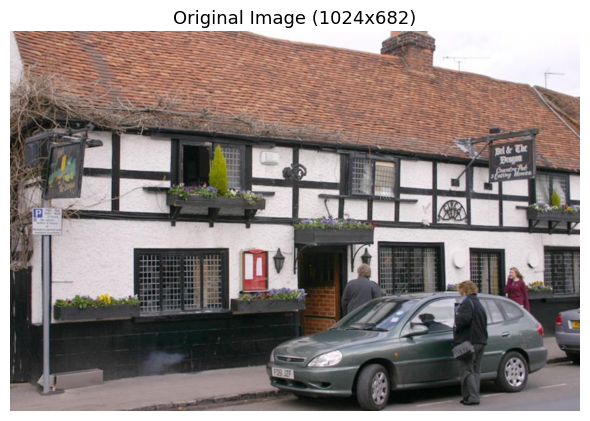

✅ Gambar berhasil dibaca: 1024x682 pixels


In [41]:
img_bgr = cv2.imread(SAMPLE_IMAGE)

if img_bgr is None:
    print(f"❌ Gambar tidak ditemukan!\n   Path: {SAMPLE_IMAGE}")
else:
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(6, 6))
    plt.imshow(img_rgb)
    plt.title(f"Original Image ({img_rgb.shape[1]}x{img_rgb.shape[0]})", fontsize=13)
    plt.axis('off')
    plt.tight_layout()
    plt.show()
    print(f"✅ Gambar berhasil dibaca: {img_rgb.shape[1]}x{img_rgb.shape[0]} pixels")


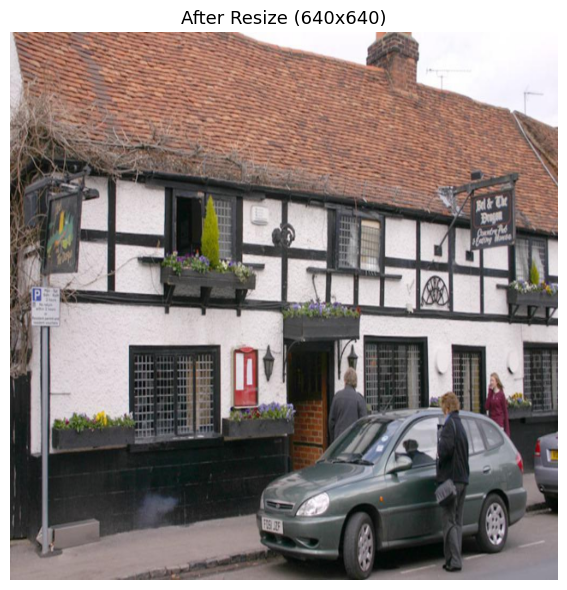

✅ Gambar berhasil diresize ke: 640x640 pixels


In [42]:
img_resized = cv2.resize(img_rgb, (640, 640))

plt.figure(figsize=(6, 6))
plt.imshow(img_resized)
plt.title("After Resize (640x640)", fontsize=13)
plt.axis('off')
plt.tight_layout()
plt.show()
print(f"✅ Gambar berhasil diresize ke: 640x640 pixels")

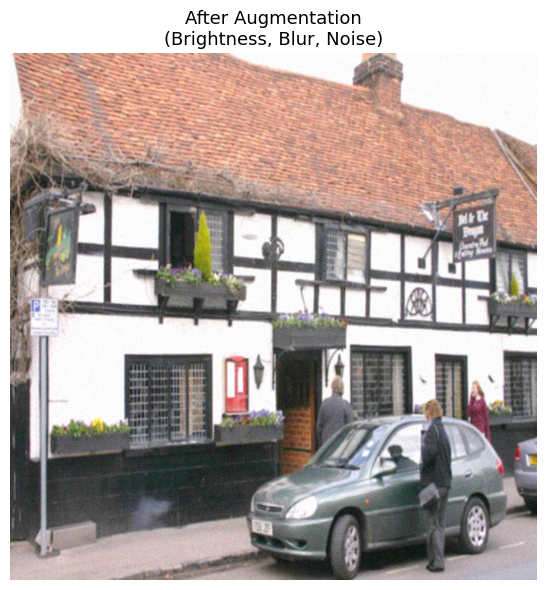

✅ Augmentasi selesai!


In [43]:
# 1. Ubah Kecerahan & Kontras
alpha = 1.2
beta  = 15
img_aug = cv2.convertScaleAbs(img_resized, alpha=alpha, beta=beta)

# 2. Gaussian Blur
img_aug = cv2.GaussianBlur(img_aug, (3, 3), 0)

# 3. Gaussian Noise - FIXED (tidak overflow) ✅
row, col, ch = img_aug.shape
gauss_noise  = np.clip(
    np.random.normal(0, 8, (row, col, ch)), -30, 30
).astype(np.int16)
img_aug = np.clip(
    img_aug.astype(np.int16) + gauss_noise, 0, 255
).astype(np.uint8)

plt.figure(figsize=(6, 6))
plt.imshow(img_aug)
plt.title("After Augmentation\n(Brightness, Blur, Noise)", fontsize=13)
plt.axis('off')
plt.tight_layout()
plt.show()
print("✅ Augmentasi selesai!")


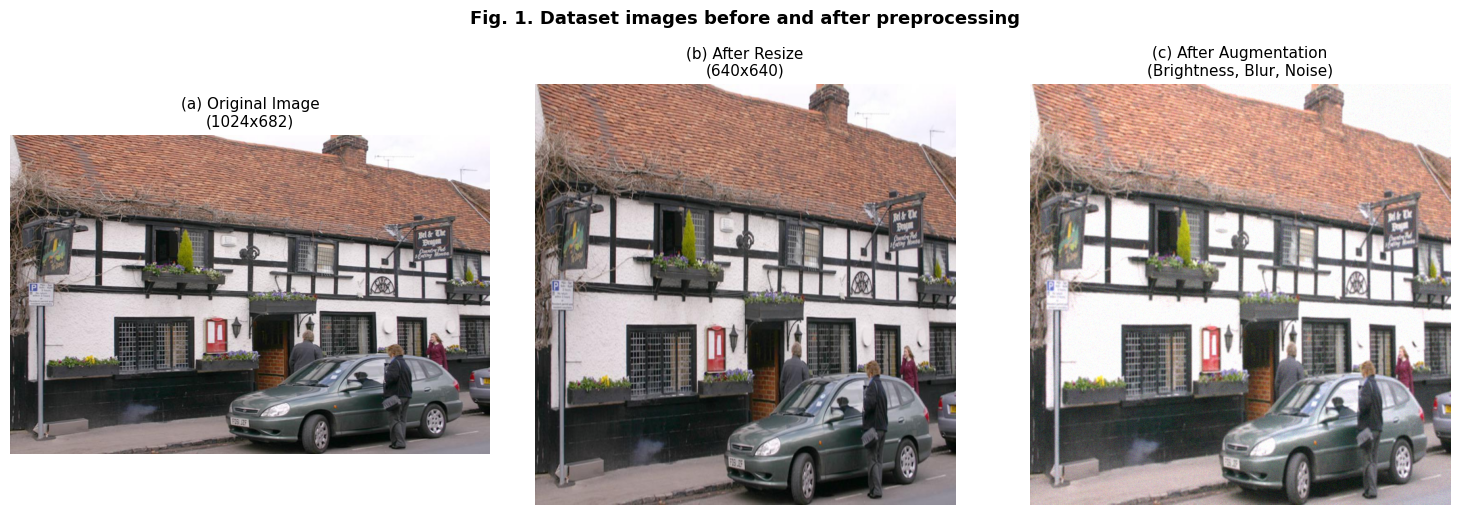

✅ Fig1_Preprocessing.png disimpan!


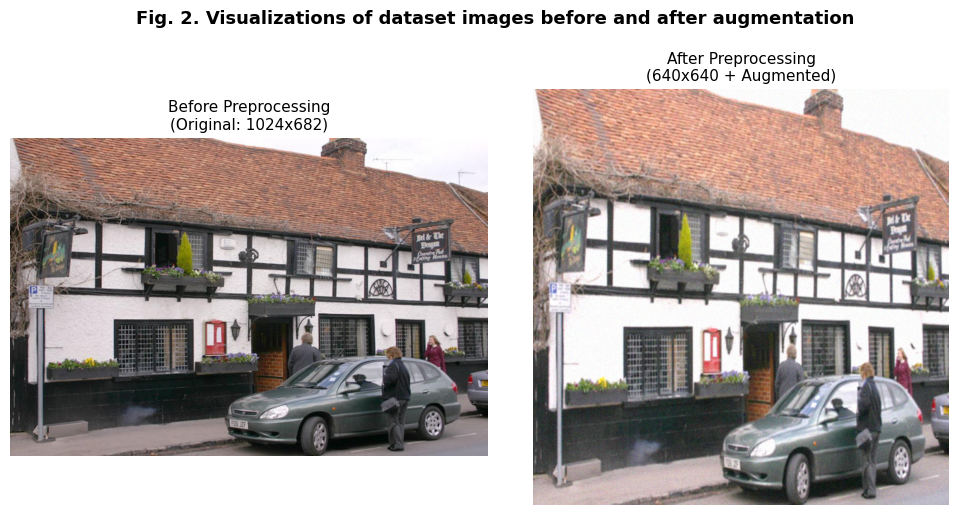

✅ Fig2_Augmentation.png disimpan!


In [44]:
# Fig. 1 - 3 panel: Original, Resize, Augmented
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(img_rgb)
axes[0].set_title(f'(a) Original Image\n({img_rgb.shape[1]}x{img_rgb.shape[0]})', fontsize=11)
axes[0].axis('off')

axes[1].imshow(img_resized)
axes[1].set_title('(b) After Resize\n(640x640)', fontsize=11)
axes[1].axis('off')

axes[2].imshow(img_aug)
axes[2].set_title('(c) After Augmentation\n(Brightness, Blur, Noise)', fontsize=11)
axes[2].axis('off')

plt.suptitle('Fig. 1. Dataset images before and after preprocessing',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('Fig1_Preprocessing.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Fig1_Preprocessing.png disimpan!")

# Fig. 2 - 2 panel: Before vs After
fig2, axes2 = plt.subplots(1, 2, figsize=(10, 5))

axes2[0].imshow(img_rgb)
axes2[0].set_title(f'Before Preprocessing\n(Original: {img_rgb.shape[1]}x{img_rgb.shape[0]})', fontsize=11)
axes2[0].axis('off')

axes2[1].imshow(img_aug)
axes2[1].set_title('After Preprocessing\n(640x640 + Augmented)', fontsize=11)
axes2[1].axis('off')

plt.suptitle('Fig. 2. Visualizations of dataset images before and after augmentation',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('Fig2_Augmentation.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Fig2_Augmentation.png disimpan!")


In [45]:
# ============================================================
# STEP 1: Buat Struktur Folder Global
# ============================================================
print("📁 Membuat struktur folder global...")
for split in ['train', 'valid', 'test']:
    os.makedirs(os.path.join(base_dst, 'images', split), exist_ok=True)
    os.makedirs(os.path.join(base_dst, 'labels', split), exist_ok=True)
print(f"✅ Folder dibuat di: {base_dst}\n")

# ============================================================
# STEP 2: Merge Semua Dataset ke Global Folder
# ============================================================
print("🔄 Memulai penggabungan dataset...\n")

merge_to_global(
    DATASET_PATHS["red_light"],
    "redlight",
    class_map_redlight
)
merge_to_global(
    DATASET_PATHS["helmet"],
    "helmet",
    class_map_helmet
)
merge_to_global(
    DATASET_PATHS["helm_spion_sepatu"],
    "spion",
    class_map_spion
)
merge_to_global(
    DATASET_PATHS["seat_belt"],
    "seatbelt",
    class_map_seatbelt
)
merge_to_global(
    DATASET_PATHS["license_plate"],
    "plate",
    class_map_plate
)

print("✅ Semua dataset berhasil digabungkan!")

# ============================================================
# STEP 3: Hitung Total Gambar
# ============================================================
print("\n" + "=" * 55)
print("  Verifikasi Dataset Global")
print("=" * 55)
total_all = 0
for split in ['train', 'valid', 'test']:
    img_folder = os.path.join(base_dst, 'images', split)
    lbl_folder = os.path.join(base_dst, 'labels', split)
    if os.path.exists(img_folder):
        n_img = len([
            f for f in os.listdir(img_folder)
            if f.lower().endswith(('.jpg','.jpeg','.png'))
        ])
        n_lbl = len([
            f for f in os.listdir(lbl_folder)
            if f.endswith('.txt')
        ]) if os.path.exists(lbl_folder) else 0
        print(f"  {split:<8}: {n_img:>6} gambar | {n_lbl:>6} label")
        total_all += n_img
print("-" * 55)
print(f"  {'Total':<8}: {total_all:>6} gambar")
print("=" * 55)


📁 Membuat struktur folder global...
✅ Folder dibuat di: D:/Tugas Kuliah/Semester 4/Research Metodology/Dataset\global

🔄 Memulai penggabungan dataset...



  Merging redlight [test]: 100%|██████████| 319/319 [00:00<00:00, 983.25it/s] 


  ✅ redlight: 3395 file berhasil di-copy!



  Merging helmet [test]: 100%|██████████| 7/7 [00:00<00:00, 938.50it/s]


  ✅ helmet: 933 file berhasil di-copy!



...

  ✅ spion: 62 file berhasil di-copy!



  Merging seatbelt [test]: 100%|██████████| 101/101 [00:00<00:00, 1101.83it/s]


  ✅ seatbelt: 1116 file berhasil di-copy!



  Merging plate [test]: 100%|██████████| 1020/1020 [00:00<00:00, 1312.87it/s]

  ✅ plate: 10125 file berhasil di-copy!

✅ Semua dataset berhasil digabungkan!

  Verifikasi Dataset Global
  train   :  11207 gambar |  11207 label
  valid   :   2974 gambar |   2974 label
  test    :   1450 gambar |   1450 label
-------------------------------------------------------
  Total   :  15631 gambar


In [46]:
# ============================================================
# Buat data.yaml Global
# ============================================================
yaml_content = f"""# Traffic Violation Detection - Global Dataset
path: {base_dst.replace(os.sep, '/')}

train: images/train
val:   images/valid
test:  images/test

nc: {NUM_CLASSES}

names:
  0:  bike
  1:  bus
  2:  car
  3:  green_light
  4:  motobike
  5:  red_light
  6:  stop_line
  7:  truck
  8:  yellow_light
  9:  license_plate
  10: with_helmet
  11: without_helmet
  12: sepatu
  13: spion
  14: tidak_pakai_sepatu
  15: mobile
  16: seatbelt
  17: windshield
"""

yaml_path = os.path.join(base_dst, 'data.yaml')
with open(yaml_path, 'w') as f:
    f.write(yaml_content)

print(f"✅ data.yaml global disimpan di:\n   {yaml_path}")
print(f"\n📋 Isi data.yaml:")
print(yaml_content)


✅ data.yaml global disimpan di:
   D:/Tugas Kuliah/Semester 4/Research Metodology/Dataset\global\data.yaml

📋 Isi data.yaml:
# Traffic Violation Detection - Global Dataset
path: D:/Tugas Kuliah/Semester 4/Research Metodology/Dataset/global

train: images/train
val:   images/valid
test:  images/test

nc: 18

names:
  0:  bike
  1:  bus
  2:  car
  3:  green_light
  4:  motobike
  5:  red_light
  6:  stop_line
  7:  truck
  8:  yellow_light
  9:  license_plate
  10: with_helmet
  11: without_helmet
  12: sepatu
  13: spion
  14: tidak_pakai_sepatu
  15: mobile
  16: seatbelt
  17: windshield



In [47]:
# Jalankan ini jika belum terinstall (hapus tanda #)
# !pip install ultralytics
# !pip install torch torchvision
# !pip install scikit-learn

from ultralytics import YOLO
import torch
import torchvision
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay
)
from PIL import Image

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f"✅ Libraries imported!")
print(f"   PyTorch version  : {torch.__version__}")
print(f"   Device           : {device}")
if torch.cuda.is_available():
    print(f"   GPU              : {torch.cuda.get_device_name(0)}")
else:
    print(f"   GPU              : Tidak tersedia (CPU mode)")

✅ Libraries imported!
   PyTorch version  : 2.11.0+cpu
   Device           : cpu
   GPU              : Tidak tersedia (CPU mode)


In [49]:
print("🚀 Memulai Training YOLOv8...")
print("-" * 50)

yaml_path  = os.path.join(base_dst, 'data.yaml')
model_yolo = YOLO('yolov8n.pt')  # n=nano | s=small | m=medium | l=large

results_yolo_train = model_yolo.train(
    data     = yaml_path,
    epochs   = 20,
    imgsz    = 416,
    batch    = 8,
    name     = 'yolov8_traffic_violation',
    device   = 0 if torch.cuda.is_available() else 'cpu',
    patience = 10,
    save     = True,
    plots    = True,
)

print("\n✅ YOLOv8 Training Selesai!")
print("   Model: runs/detect/yolov8_traffic_violation/weights/best.pt")


🚀 Memulai Training YOLOv8...
--------------------------------------------------
Ultralytics 8.4.48  Python-3.13.9 torch-2.11.0+cpu CPU (13th Gen Intel Core i7-13700H)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=D:/Tugas Kuliah/Semester 4/Research Metodology/Dataset\global\data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=416, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, 

KeyboardInterrupt: 

In [ ]:
print("📊 Mengevaluasi YOLOv8 pada Test Set...")

best_yolo_path = 'runs/detect/yolov8_traffic_violation/weights/best.pt'
trained_yolo   = YOLO(best_yolo_path)

metrics_yolo = trained_yolo.val(
    data  = yaml_path,
    split = 'test',
    imgsz = 640,
)

map50_yolo     = metrics_yolo.box.map50
map5095_yolo   = metrics_yolo.box.map
precision_yolo = metrics_yolo.box.mp
recall_yolo    = metrics_yolo.box.mr
f1_yolo        = 2 * (precision_yolo * recall_yolo) / (precision_yolo + recall_yolo + 1e-10)

# Hitung FPS
sample_imgs = glob.glob(os.path.join(base_dst, 'images/test/*.jpg'))[:10]
if not sample_imgs:
    sample_imgs = glob.glob(os.path.join(base_dst, 'images/test/*.png'))[:10]

start_time = time.time()
for img_path in sample_imgs:
    trained_yolo.predict(img_path, verbose=False)
end_time = time.time()

fps_yolo          = len(sample_imgs) / (end_time - start_time)
inference_ms_yolo = 1000 / fps_yolo

print("\n" + "=" * 50)
print("       YOLOv8 Evaluation Results")
print("=" * 50)
print(f"  mAP@0.5          : {map50_yolo:.4f}")
print(f"  mAP@0.5:0.95     : {map5095_yolo:.4f}")
print(f"  Precision        : {precision_yolo:.4f}")
print(f"  Recall           : {recall_yolo:.4f}")
print(f"  F1-Score         : {f1_yolo:.4f}")
print(f"  FPS              : {fps_yolo:.2f}")
print(f"  Inference Time   : {inference_ms_yolo:.2f} ms/image")
print("=" * 50)

In [ ]:
class TrafficViolationDataset(Dataset):
    """
    Custom Dataset untuk Faster R-CNN.
    Konversi format YOLO (normalized xywh) → Faster R-CNN (xyxy absolute).
    """
    def __init__(self, img_dir, lbl_dir, transforms=None):
        self.img_dir    = img_dir
        self.lbl_dir    = lbl_dir
        self.transforms = transforms
        self.imgs       = sorted([
            f for f in os.listdir(img_dir)
            if f.lower().endswith(('.jpg', '.jpeg', '.png'))
        ])
        print(f"  Dataset loaded: {len(self.imgs)} images")

    def __len__(self):
        return len(self.imgs)

    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.imgs[idx])
        img      = Image.open(img_path).convert("RGB")
        w, h     = img.size

        lbl_path = os.path.join(
            self.lbl_dir,
            os.path.splitext(self.imgs[idx])[0] + '.txt'
        )

        boxes, labels = [], []

        if os.path.exists(lbl_path):
            with open(lbl_path, 'r') as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) < 5:
                        continue
                    cls_id = int(parts[0])
                    cx = float(parts[1]) * w
                    cy = float(parts[2]) * h
                    bw = float(parts[3]) * w
                    bh = float(parts[4]) * h
                    x1 = max(0, cx - bw / 2)
                    y1 = max(0, cy - bh / 2)
                    x2 = min(w, cx + bw / 2)
                    y2 = min(h, cy + bh / 2)
                    if x2 > x1 and y2 > y1:
                        boxes.append([x1, y1, x2, y2])
                        labels.append(cls_id + 1)  # +1 untuk background

        if len(boxes) == 0:
            boxes  = torch.zeros((0, 4), dtype=torch.float32)
            labels = torch.zeros((0,),   dtype=torch.int64)
            area   = torch.zeros((0,),   dtype=torch.float32)
        else:
            boxes  = torch.as_tensor(boxes,  dtype=torch.float32)
            labels = torch.as_tensor(labels, dtype=torch.int64)
            area   = (boxes[:, 3] - boxes[:, 1]) * (boxes[:, 2] - boxes[:, 0])

        target = {
            "boxes"    : boxes,
            "labels"   : labels,
            "area"     : area,
            "iscrowd"  : torch.zeros((len(labels),), dtype=torch.int64),
            "image_id" : torch.tensor([idx]),
        }

        img = T.ToTensor()(img)
        return img, target


def collate_fn(batch):
    return tuple(zip(*batch))


print("📦 Membuat DataLoader...")
dataset_train = TrafficViolationDataset(
    os.path.join(base_dst, 'images', 'train'),
    os.path.join(base_dst, 'labels', 'train'),
)
dataset_valid = TrafficViolationDataset(
    os.path.join(base_dst, 'images', 'valid'),
    os.path.join(base_dst, 'labels', 'valid'),
)
dataset_test = TrafficViolationDataset(
    os.path.join(base_dst, 'images', 'test'),
    os.path.join(base_dst, 'labels', 'test'),
)

loader_train = DataLoader(dataset_train, batch_size=4, shuffle=True,
                          num_workers=2, collate_fn=collate_fn)
loader_valid = DataLoader(dataset_valid, batch_size=4, shuffle=False,
                          num_workers=2, collate_fn=collate_fn)
loader_test  = DataLoader(dataset_test,  batch_size=1, shuffle=False,
                          num_workers=0, collate_fn=collate_fn)

print(f"\n✅ DataLoader siap!")
print(f"   Train : {len(dataset_train)} gambar")
print(f"   Valid : {len(dataset_valid)} gambar")
print(f"   Test  : {len(dataset_test)} gambar")

In [ ]:
def get_fasterrcnn_model(num_classes):
    model      = fasterrcnn_resnet50_fpn(weights='DEFAULT')
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(
        in_features, num_classes + 1
    )
    return model

model_frcnn = get_fasterrcnn_model(NUM_CLASSES)
model_frcnn.to(device)

params           = [p for p in model_frcnn.parameters() if p.requires_grad]
optimizer_frcnn  = torch.optim.SGD(params, lr=0.005, momentum=0.9, weight_decay=0.0005)
lr_scheduler     = torch.optim.lr_scheduler.StepLR(optimizer_frcnn, step_size=3, gamma=0.1)

print("✅ Faster R-CNN model siap!")
print(f"   Device      : {device}")
print(f"   Parameters  : {sum(p.numel() for p in model_frcnn.parameters()):,}")
print(f"   Num Classes : {NUM_CLASSES} + 1 (background)")

In [ ]:
NUM_EPOCHS_FRCNN = 10
train_losses     = []
best_loss        = float('inf')

print(f"🚀 Training Faster R-CNN ({NUM_EPOCHS_FRCNN} epochs)...")
print("-" * 60)

for epoch in range(NUM_EPOCHS_FRCNN):
    model_frcnn.train()
    epoch_loss  = 0.0
    batch_count = 0

    loop = tqdm(loader_train, desc=f"Epoch [{epoch+1}/{NUM_EPOCHS_FRCNN}]")

    for images, targets in loop:
        images  = list(img.to(device) for img in images)
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        if any(len(t['boxes']) == 0 for t in targets):
            continue

        loss_dict = model_frcnn(images, targets)
        losses    = sum(loss for loss in loss_dict.values())

        optimizer_frcnn.zero_grad()
        losses.backward()
        optimizer_frcnn.step()

        epoch_loss  += losses.item()
        batch_count += 1
        loop.set_postfix(loss=f"{losses.item():.4f}")

    avg_loss = epoch_loss / max(batch_count, 1)
    train_losses.append(avg_loss)
    lr_scheduler.step()

    print(f"  Epoch {epoch+1:02d}/{NUM_EPOCHS_FRCNN} | Avg Loss: {avg_loss:.4f}")

    if avg_loss < best_loss:
        best_loss = avg_loss
        torch.save(model_frcnn.state_dict(), 'best_fasterrcnn.pth')
        print(f"  💾 Model terbaik disimpan! (loss: {best_loss:.4f})")

# Plot Training Loss - Fig. 3
plt.figure(figsize=(8, 4))
plt.plot(range(1, NUM_EPOCHS_FRCNN + 1), train_losses, 'b-o', linewidth=2, markersize=5)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('Fig. 3. Faster R-CNN Training Loss per Epoch', fontsize=13, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('Fig3_FRCNN_TrainingLoss.png', dpi=300)
plt.show()
print("\n✅ Faster R-CNN Training Selesai!")

In [ ]:
def compute_iou(box1, box2):
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])
    intersection = max(0, x2 - x1) * max(0, y2 - y1)
    area1 = (box1[2] - box1[0]) * (box1[3] - box1[1])
    area2 = (box2[2] - box2[0]) * (box2[3] - box2[1])
    union = area1 + area2 - intersection
    return intersection / union if union > 0 else 0


def evaluate_fasterrcnn(model, dataloader, iou_threshold=0.5):
    model.eval()
    all_true, all_pred = [], []
    inf_times = []

    with torch.no_grad():
        for images, targets in tqdm(dataloader, desc="Evaluating Faster R-CNN"):
            images = list(img.to(device) for img in images)
            start  = time.time()
            preds  = model(images)
            inf_times.append(time.time() - start)

            for pred, target in zip(preds, targets):
                gt_boxes    = target['boxes'].cpu().numpy()
                gt_labels   = target['labels'].cpu().numpy()
                pred_boxes  = pred['boxes'].cpu().numpy()
                pred_scores = pred['scores'].cpu().numpy()
                pred_labels = pred['labels'].cpu().numpy()

                mask        = pred_scores >= 0.5
                pred_boxes  = pred_boxes[mask]
                pred_labels = pred_labels[mask]

                if len(gt_boxes) > 0 and len(pred_boxes) > 0:
                    for gt_box, gt_label in zip(gt_boxes, gt_labels):
                        best_iou, best_pl = 0, 0
                        for pb, pl in zip(pred_boxes, pred_labels):
                            iou = compute_iou(gt_box, pb)
                            if iou > best_iou:
                                best_iou, best_pl = iou, pl
                        all_true.append(int(gt_label))
                        all_pred.append(int(best_pl) if best_iou >= iou_threshold else 0)
                elif len(gt_boxes) > 0:
                    for gl in gt_labels:
                        all_true.append(int(gl))
                        all_pred.append(0)

    avg_inf_time = np.mean(inf_times) * 1000
    fps          = 1000 / avg_inf_time
    return all_true, all_pred, avg_inf_time, fps


# Load model terbaik
print("📊 Loading model Faster R-CNN terbaik...")
model_frcnn.load_state_dict(torch.load('best_fasterrcnn.pth'))

print("📊 Mengevaluasi pada Test Set...")
y_true_raw, y_pred_raw, inf_time_frcnn, fps_frcnn = evaluate_fasterrcnn(
    model_frcnn, loader_test
)

# Filter background (label 0) & konversi ke 0-indexed
y_true_f = [y - 1 for y in y_true_raw if y > 0]
y_pred_f = [max(0, y_pred_raw[i] - 1) for i, y in enumerate(y_true_raw) if y > 0]

precision_frcnn = precision_score(y_true_f, y_pred_f, average='weighted', zero_division=0)
recall_frcnn    = recall_score(y_true_f, y_pred_f, average='weighted', zero_division=0)
f1_frcnn        = f1_score(y_true_f, y_pred_f, average='weighted', zero_division=0)

print("\n" + "=" * 50)
print("    Faster R-CNN Evaluation Results")
print("=" * 50)
print(f"  Precision      : {precision_frcnn:.4f}")
print(f"  Recall         : {recall_frcnn:.4f}")
print(f"  F1-Score       : {f1_frcnn:.4f}")
print(f"  Inference Time : {inf_time_frcnn:.2f} ms/image")
print(f"  FPS            : {fps_frcnn:.2f}")
print("=" * 50)

In [ ]:
results = {
    'Model'         : ['YOLOv8', 'Faster R-CNN'],
    'Precision'     : [round(precision_yolo,  4), round(precision_frcnn, 4)],
    'Recall'        : [round(recall_yolo,     4), round(recall_frcnn,    4)],
    'F1-Score'      : [round(f1_yolo,         4), round(f1_frcnn,        4)],
    'mAP@0.5'       : [round(map50_yolo,      4), 'N/A'],
    'Inference (ms)': [round(inference_ms_yolo, 2), round(inf_time_frcnn, 2)],
    'FPS'           : [round(fps_yolo,          2), round(fps_frcnn,      2)],
}

df_results = pd.DataFrame(results).set_index('Model')

print("=" * 70)
print("        Perbandingan YOLOv8 vs Faster R-CNN")
print("=" * 70)
print(df_results.to_string())
print("=" * 70)

df_results.to_csv('comparison_results.csv')
print("\n✅ Tersimpan ke 'comparison_results.csv'")

In [ ]:
metrics_val = {
    'Precision': [precision_yolo,  precision_frcnn],
    'Recall'   : [recall_yolo,     recall_frcnn],
    'F1-Score' : [f1_yolo,         f1_frcnn],
}
models  = ['YOLOv8', 'Faster R-CNN']
x       = np.arange(len(models))
width   = 0.25
colors  = ['#2196F3', '#FF5722', '#4CAF50']

fig, ax = plt.subplots(figsize=(10, 6))

for i, (metric, values) in enumerate(metrics_val.items()):
    bars = ax.bar(x + i * width, values, width,
                  label=metric, color=colors[i],
                  alpha=0.85, edgecolor='black', linewidth=0.5)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2.,
                bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', va='bottom',
                fontsize=9, fontweight='bold')

ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Fig. 4. Performance Comparison: YOLOv8 vs Faster R-CNN',
             fontsize=13, fontweight='bold')
ax.set_xticks(x + width)
ax.set_xticklabels(models, fontsize=11)
ax.set_ylim(0, 1.15)
ax.legend(title='Metrics', fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig('Fig4_ModelComparison.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Fig4_ModelComparison.png disimpan!")

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# FPS
fps_values  = [fps_yolo, fps_frcnn]
bar_colors  = ['#4CAF50', '#FF9800']
bars = axes[0].bar(models, fps_values, color=bar_colors,
                   alpha=0.85, edgecolor='black', width=0.4)
for bar, val in zip(bars, fps_values):
    axes[0].text(bar.get_x() + bar.get_width() / 2.,
                 bar.get_height() + 0.5,
                 f'{val:.1f} FPS', ha='center', va='bottom',
                 fontsize=11, fontweight='bold')
axes[0].set_ylabel('Frames Per Second (FPS)', fontsize=11)
axes[0].set_title('Inference Speed (FPS)', fontsize=12, fontweight='bold')
axes[0].grid(axis='y', linestyle='--', alpha=0.6)

# Inference Time
inf_values  = [inference_ms_yolo, inf_time_frcnn]
bar_colors2 = ['#2196F3', '#E91E63']
bars2 = axes[1].bar(models, inf_values, color=bar_colors2,
                    alpha=0.85, edgecolor='black', width=0.4)
for bar, val in zip(bars2, inf_values):
    axes[1].text(bar.get_x() + bar.get_width() / 2.,
                 bar.get_height() + 0.5,
                 f'{val:.1f} ms', ha='center', va='bottom',
                 fontsize=11, fontweight='bold')
axes[1].set_ylabel('Inference Time (ms/image)', fontsize=11)
axes[1].set_title('Inference Time per Image', fontsize=12, fontweight='bold')
axes[1].grid(axis='y', linestyle='--', alpha=0.6)

plt.suptitle('Fig. 5. Speed Comparison: YOLOv8 vs Faster R-CNN',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('Fig5_SpeedComparison.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Fig5_SpeedComparison.png disimpan!")

In [ ]:
class_labels = list(CLASS_NAMES.values())

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Confusion Matrix Faster R-CNN
if len(y_true_f) > 0:
    cm_frcnn  = confusion_matrix(y_true_f, y_pred_f,
                                  labels=list(range(NUM_CLASSES)))
    disp_frcnn = ConfusionMatrixDisplay(confusion_matrix=cm_frcnn,
                                        display_labels=class_labels)
    disp_frcnn.plot(ax=axes[1], colorbar=False, cmap='Blues',
                    xticks_rotation=45)
    axes[1].set_title('(b) Faster R-CNN\nConfusion Matrix',
                      fontsize=12, fontweight='bold')

# YOLOv8 Confusion Matrix (auto-generated oleh ultralytics)
axes[0].text(0.5, 0.5,
             'YOLOv8 Confusion Matrix\n'
             'Auto-generated di folder:\n'
             'runs/detect/yolov8_traffic_violation/',
             ha='center', va='center', fontsize=11,
             bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))
axes[0].set_title('(a) YOLOv8\nConfusion Matrix',
                  fontsize=12, fontweight='bold')
axes[0].axis('off')

plt.suptitle('Fig. 6. Confusion Matrix: YOLOv8 vs Faster R-CNN',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('Fig6_ConfusionMatrix.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Fig6_ConfusionMatrix.png disimpan!")

In [ ]:
print("=" * 70)
print("      Classification Report - Faster R-CNN")
print("=" * 70)
if len(y_true_f) > 0:
    print(classification_report(
        y_true_f, y_pred_f,
        target_names=class_labels,
        zero_division=0
    ))

In [ ]:
sample_imgs = glob.glob(os.path.join(base_dst, 'images/test/*.jpg'))[:4]
if not sample_imgs:
    sample_imgs = glob.glob(os.path.join(base_dst, 'images/test/*.png'))[:4]

if sample_imgs:
    fig, axes = plt.subplots(1, len(sample_imgs), figsize=(16, 4))
    if len(sample_imgs) == 1:
        axes = [axes]

    print("🔍 Menjalankan inferensi YOLOv8...")
    for i, img_path in enumerate(sample_imgs):
        result = trained_yolo.predict(img_path, verbose=False, conf=0.3)[0]
        img_with_boxes = cv2.cvtColor(result.plot(), cv2.COLOR_BGR2RGB)
        axes[i].imshow(img_with_boxes)
        axes[i].set_title(f'Sample {i+1}', fontsize=10)
        axes[i].axis('off')

    plt.suptitle('Fig. 7. YOLOv8 Detection Results on Test Set Samples',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('Fig7_YOLOv8_Detections.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("✅ Fig7_YOLOv8_Detections.png disimpan!")

In [ ]:
print("=" * 70)
print("          RINGKASAN HASIL UNTUK PAPER")
print("=" * 70)
print(f"\n📊 Dataset:")
print(f"   Total gambar    : {total_all} gambar")
print(f"   Jumlah kelas    : {NUM_CLASSES} kelas")
print(f"   Ukuran input    : 640 x 640 pixels")

print(f"\n📊 Hasil Evaluasi Model:")
print(f"   {'Metric':<20} {'YOLOv8':>12} {'Faster R-CNN':>15}")
print(f"   {'-'*48}")
print(f"   {'Precision':<20} {precision_yolo:>12.4f} {precision_frcnn:>15.4f}")
print(f"   {'Recall':<20} {recall_yolo:>12.4f} {recall_frcnn:>15.4f}")
print(f"   {'F1-Score':<20} {f1_yolo:>12.4f} {f1_frcnn:>15.4f}")
print(f"   {'mAP@0.5':<20} {map50_yolo:>12.4f} {'N/A':>15}")
print(f"   {'Inference (ms)':<20} {inference_ms_yolo:>11.2f}ms {inf_time_frcnn:>14.2f}ms")
print(f"   {'FPS':<20} {fps_yolo:>12.2f} {fps_frcnn:>15.2f}")

best_acc = "YOLOv8" if f1_yolo > f1_frcnn else "Faster R-CNN"
best_spd = "YOLOv8" if fps_yolo > fps_frcnn else "Faster R-CNN"

print(f"\n🏆 Kesimpulan:")
print(f"   Model terbaik (F1-Score) : {best_acc}")
print(f"   Model tercepat (FPS)     : {best_spd}")

print(f"\n📁 File yang tersimpan untuk Paper:")
saved_files = [
    ('Fig1_Preprocessing.png',    'Bab 3 - Preprocessing'),
    ('Fig2_Augmentation.png',     'Bab 3 - Augmentation'),
    ('Fig3_FRCNN_TrainingLoss.png','Bab 4 - Training Loss'),
    ('Fig4_ModelComparison.png',  'Bab 4 - Metrics Comparison'),
    ('Fig5_SpeedComparison.png',  'Bab 4 - Speed Comparison'),
    ('Fig6_ConfusionMatrix.png',  'Bab 4 - Confusion Matrix'),
    ('Fig7_YOLOv8_Detections.png','Bab 4 - Visual Detection'),
    ('comparison_results.csv',    'Data mentah hasil evaluasi'),
]
for fname, keterangan in saved_files:
    status = "✅" if os.path.exists(fname) else "❌"
    print(f"   {status} {fname:<35} → {keterangan}")

print("\n" + "=" * 70)